<a href="https://colab.research.google.com/github/MMujtabaX/Bagging-Random-Forest/blob/main/bagging_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  From Bagging to Random Forest
### AtomCamp — Machine Learning Fundamentals

---

**What we'll cover in this notebook:**
1. Why a single Decision Tree overfits
2. What Bootstrap Sampling is
3. Bagging from scratch (manual)
4. Bagging with sklearn
5. The problem with Bagging → correlated trees
6. Random Forest — the fix
7. Feature Importance
8. Hyperparameter Tuning
9. Final comparison: Tree vs Bagging vs Random Forest

##  0. Setup — Install & Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

# Consistent random state throughout
SEED = 42
np.random.seed(SEED)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
## 🌱 1. The Problem — One Tree Overfits

Before we fix a problem, let's **see** the problem clearly.

We'll generate a dataset and show how a single Decision Tree overfits — it memorises training data but fails on new data.

In [ ]:
# Generate a dataset
X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=SEED
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"Classes          : {np.unique(y)}")

Training samples : 400
Test samples     : 100
Features         : 20
Classes          : [0 1]


In [ ]:
# Train a fully grown Decision Tree (no limits = overfit)
dt = DecisionTreeClassifier(random_state=SEED)  # No max_depth = grows until pure
dt.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print("=" * 40)
print("  Single Decision Tree")
print("=" * 40)
print(f"  Train Accuracy : {train_acc:.4f}  ← memorises training data")
print(f"  Test  Accuracy : {test_acc:.4f}  ← fails on new data")
print(f"  Tree Depth     : {dt.get_depth()}  ← very deep = overfitting")
print(f"  Leaves         : {dt.get_n_leaves()}")
print("=" * 40)
print(f"\n  Gap (overfit)  : {train_acc - test_acc:.4f}  ← large gap = problem!")

  Single Decision Tree
  Train Accuracy : 1.0000  ← memorises training data
  Test  Accuracy : 0.9000  ← fails on new data
  Tree Depth     : 13  ← very deep = overfitting
  Leaves         : 47

  Gap (overfit)  : 0.1000  ← large gap = problem!


**See that gap?**  
Train accuracy is near 100%, but test accuracy is much lower.  
The tree memorised the training set — it hasn't *learned*, it's *cheating*.

> 💡 **Key Insight:** A fully grown tree has very low bias but very high variance.  
> Change the training data slightly → completely different tree.

---
## 🎲 2. Bootstrap Sampling — The Foundation of Bagging

Before building Bagging, we need to understand **bootstrap sampling**.

> **Bootstrap** = Sample your dataset WITH replacement.  
> Each sample is the same size as the original, but some rows appear multiple times and some don't appear at all.

On average, each bootstrap sample contains about **63.2%** of the original rows (unique).  
The remaining ~37% are called the **Out-Of-Bag (OOB)** samples — useful for free validation!

In [ ]:
# Let's see bootstrap sampling in action with a tiny example
original_data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
n = len(original_data)

print("Original data:", original_data)
print("-" * 50)

for i in range(5):
    bootstrap_sample = np.random.choice(original_data, size=n, replace=True)
    unique_in_sample = set(bootstrap_sample)
    out_of_bag = set(original_data) - unique_in_sample

    print(f"Bootstrap {i+1}: {sorted(bootstrap_sample)}")
    print(f"           Unique: {sorted(unique_in_sample)} | OOB: {sorted(out_of_bag)}")
    print()

Original data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
--------------------------------------------------
Bootstrap 1: [3, 4, 5, 5, 7, 7, 7, 8, 8, 10]
           Unique: [3, 4, 5, 7, 8, 10] | OOB: [1, 2, 6, 9]

Bootstrap 2: [2, 2, 3, 4, 5, 6, 6, 8, 8, 8]
           Unique: [2, 3, 4, 5, 6, 8] | OOB: [1, 7, 9, 10]

Bootstrap 3: [1, 1, 3, 4, 5, 6, 7, 9, 10, 10]
           Unique: [1, 3, 4, 5, 6, 7, 9, 10] | OOB: [2, 8]

Bootstrap 4: [2, 3, 3, 4, 5, 5, 7, 7, 9, 9]
           Unique: [2, 3, 4, 5, 7, 9] | OOB: [1, 6, 8, 10]

Bootstrap 5: [2, 2, 4, 5, 7, 8, 9, 9, 10, 10]
           Unique: [2, 4, 5, 7, 8, 9, 10] | OOB: [1, 3, 6]



In [ ]:
# Verify the 63.2% rule empirically
n_samples = 1000
n_trials = 10000
unique_fractions = []

for _ in range(n_trials):
    bootstrap = np.random.choice(n_samples, size=n_samples, replace=True)
    unique_fractions.append(len(set(bootstrap)) / n_samples)

avg_unique = np.mean(unique_fractions)
theoretical = 1 - (1/np.e)  # 1 - 1/e ≈ 0.632

print(f"Empirical average unique fraction : {avg_unique:.4f}")
print(f"Theoretical (1 - 1/e)             : {theoretical:.4f}")
print(f"Difference                         : {abs(avg_unique - theoretical):.4f}")
print("\n✅ The 63.2% rule holds!")

Empirical average unique fraction : 0.6323
Theoretical (1 - 1/e)             : 0.6321
Difference                         : 0.0002

✅ The 63.2% rule holds!


---
## 🛍️ 3. Bagging — Manual Implementation

Let's build Bagging **from scratch** so you understand exactly what's happening under the hood.  
The idea is simple:

```
FOR each tree in n_trees:
    1. Draw a bootstrap sample from training data
    2. Train a Decision Tree on that sample
    
TO PREDICT:
    Each tree votes → take majority vote
```

In [ ]:
class ManualBagging:
    """
    Manual implementation of Bagging from scratch.
    Purely for teaching — shows exactly what happens inside.
    """

    def __init__(self, n_estimators=10, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.trees = []
        n_samples = X.shape[0]

        for i in range(self.n_estimators):
            # Step 1: Bootstrap sample
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_boot, y_boot = X[indices], y[indices]

            # Step 2: Train a full decision tree on the bootstrap sample
            tree = DecisionTreeClassifier(random_state=i)
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

        return self

    def predict(self, X):
        # Each tree votes
        votes = np.array([tree.predict(X) for tree in self.trees])  # shape: (n_trees, n_samples)

        # Majority vote for each sample
        predictions = []
        for i in range(X.shape[0]):
            sample_votes = votes[:, i]
            majority = np.bincount(sample_votes).argmax()
            predictions.append(majority)

        return np.array(predictions)


# Test our manual implementation
manual_bag = ManualBagging(n_estimators=50, random_state=SEED)
manual_bag.fit(X_train, y_train)

manual_train_acc = accuracy_score(y_train, manual_bag.predict(X_train))
manual_test_acc  = accuracy_score(y_test,  manual_bag.predict(X_test))

print("=" * 40)
print("  Manual Bagging (50 trees)")
print("=" * 40)
print(f"  Train Accuracy : {manual_train_acc:.4f}")
print(f"  Test  Accuracy : {manual_test_acc:.4f}")
print(f"  Gap            : {manual_train_acc - manual_test_acc:.4f}")
print("=" * 40)

  Manual Bagging (50 trees)
  Train Accuracy : 1.0000
  Test  Accuracy : 0.8900
  Gap            : 0.1100


---
## 📈 4. Does More Trees = Better? The Convergence Plot

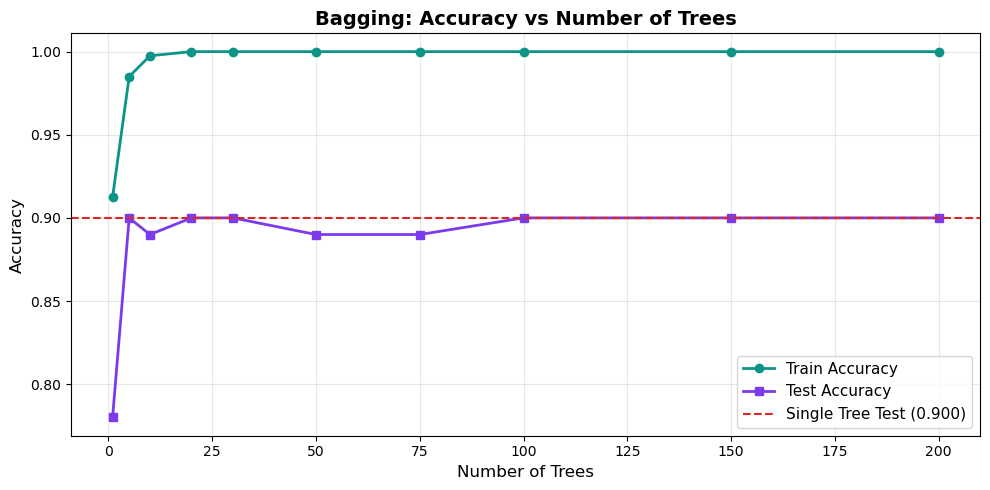


💡 Key Observation:
  → Test accuracy improves and stabilises as we add trees
  → After a point, more trees don't help much — it converges
  → But unlike a single tree, the gap between train/test narrows


In [ ]:
# How does accuracy change as we add more trees?
n_trees_range = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_trees_range:
    bag = BaggingClassifier(n_estimators=n, random_state=SEED)
    bag.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, bag.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  bag.predict(X_test)))

# Single tree baseline
single_tree_test = accuracy_score(y_test, dt.predict(X_test))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_range, train_scores, 'o-', color='#0D9488', linewidth=2, label='Train Accuracy')
plt.plot(n_trees_range, test_scores,  's-', color='#7C3AED', linewidth=2, label='Test Accuracy')
plt.axhline(y=single_tree_test, color='#DC2626', linestyle='--', linewidth=1.5, label=f'Single Tree Test ({single_tree_test:.3f})')
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Bagging: Accuracy vs Number of Trees', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Key Observation:")
print("  → Test accuracy improves and stabilises as we add trees")
print("  → After a point, more trees don't help much — it converges")
print("  → But unlike a single tree, the gap between train/test narrows")

---
## ⚠️ 5. The Problem With Bagging — Correlated Trees

Bagging is better than a single tree — but it has a weakness.

If one feature is **very strong** (e.g. it has very high Information Gain), every single bootstrapped tree will use that feature for its first split.  
This means all trees look similar → they are **correlated** → they make the same mistakes.

**Correlated errors don't cancel out.**

In [ ]:
# Let's DEMONSTRATE tree correlation in Bagging
# We'll train 10 bagged trees and look at what feature they all split on first

bag_demo = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=0),
    n_estimators=10,
    random_state=SEED,
    bootstrap=True
)
bag_demo.fit(X_train, y_train)

print("First split feature index in each Bagged tree:")
print("-" * 45)
first_features = []
for i, estimator in enumerate(bag_demo.estimators_):
    first_feature = estimator.tree_.feature[0]  # Root node feature
    first_features.append(first_feature)
    print(f"  Tree {i+1:2d}: splits on Feature {first_feature}")

from collections import Counter
counts = Counter(first_features)
most_common = counts.most_common(1)[0]
print(f"\n  ⚠️  Feature {most_common[0]} used in {most_common[1]}/10 trees as root split")
print("  → Trees are CORRELATED — all relying on the same strong feature")

First split feature index in each Bagged tree:
---------------------------------------------
  Tree  1: splits on Feature 19
  Tree  2: splits on Feature 0
  Tree  3: splits on Feature 0
  Tree  4: splits on Feature 0
  Tree  5: splits on Feature 0
  Tree  6: splits on Feature 0
  Tree  7: splits on Feature 0
  Tree  8: splits on Feature 19
  Tree  9: splits on Feature 0
  Tree 10: splits on Feature 0

  ⚠️  Feature 0 used in 8/10 trees as root split
  → Trees are CORRELATED — all relying on the same strong feature


---
## 🌳🌳🌳 6. Random Forest — The Fix

Random Forest adds **one crucial change** to Bagging:

> **At each split, consider only a random subset of features (not all of them).**

This **forces** trees to look at different features → trees become **decorrelated** → different trees make different mistakes → errors cancel out better.

| | Bagging | Random Forest |
|--|---------|---------------|
| Bootstrap sampling | ✅ | ✅ |
| Full feature set at each split | ✅ | ❌ |
| Random feature subset at each split | ❌ | ✅ |
| Trees correlated | ⚠️ High | ✅ Low |

**Rule of thumb for `max_features`:**
- Classification → `sqrt(n_features)`
- Regression → `n_features / 3`

In [ ]:
# Random Forest — verify trees are now decorrelated
rf_demo = RandomForestClassifier(n_estimators=10, random_state=SEED)
rf_demo.fit(X_train, y_train)

print("First split feature index in each Random Forest tree:")
print("-" * 50)
rf_first_features = []
for i, estimator in enumerate(rf_demo.estimators_):
    first_feature = estimator.tree_.feature[0]
    rf_first_features.append(first_feature)
    print(f"  Tree {i+1:2d}: splits on Feature {first_feature}")

rf_counts = Counter(rf_first_features)
rf_most_common = rf_counts.most_common(1)[0]
print(f"\n  ✅ Feature {rf_most_common[0]} used in only {rf_most_common[1]}/10 trees as root split")
print(f"  → {len(rf_counts)} different features used as root splits across trees")
print("  → Trees are now DECORRELATED!")

First split feature index in each Random Forest tree:
--------------------------------------------------
  Tree  1: splits on Feature 0
  Tree  2: splits on Feature 3
  Tree  3: splits on Feature 19
  Tree  4: splits on Feature 0
  Tree  5: splits on Feature 19
  Tree  6: splits on Feature 0
  Tree  7: splits on Feature 5
  Tree  8: splits on Feature 0
  Tree  9: splits on Feature 7
  Tree 10: splits on Feature 4

  ✅ Feature 0 used in only 4/10 trees as root split
  → 6 different features used as root splits across trees
  → Trees are now DECORRELATED!


In [ ]:
# Full comparison: Single Tree vs Bagging vs Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
bag = BaggingClassifier(n_estimators=100, random_state=SEED)

rf.fit(X_train, y_train)
bag.fit(X_train, y_train)

results = {
    'Single Tree': {
        'train': accuracy_score(y_train, dt.predict(X_train)),
        'test':  accuracy_score(y_test,  dt.predict(X_test))
    },
    'Bagging (100 trees)': {
        'train': accuracy_score(y_train, bag.predict(X_train)),
        'test':  accuracy_score(y_test,  bag.predict(X_test))
    },
    'Random Forest (100 trees)': {
        'train': accuracy_score(y_train, rf.predict(X_train)),
        'test':  accuracy_score(y_test,  rf.predict(X_test))
    }
}

print("=" * 60)
print(f"{'Model':<28} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("=" * 60)
for model, scores in results.items():
    gap = scores['train'] - scores['test']
    print(f"{model:<28} {scores['train']:>8.4f} {scores['test']:>8.4f} {gap:>8.4f}")
print("=" * 60)

Model                           Train     Test      Gap
Single Tree                    1.0000   0.9000   0.1000
Bagging (100 trees)            1.0000   0.9000   0.1000
Random Forest (100 trees)      1.0000   0.8900   0.1100


---
## 🔬 7. Real Dataset — Breast Cancer

Let's apply everything to a real dataset with medical significance.  
The **Breast Cancer Wisconsin** dataset: predict malignant vs benign from 30 features.

In [ ]:
# Load real dataset
cancer = load_breast_cancer()
X_c = cancer.data
y_c = cancer.target
feature_names = cancer.feature_names

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=SEED
)

print(f"Dataset       : Breast Cancer Wisconsin")
print(f"Total samples : {X_c.shape[0]}")
print(f"Features      : {X_c.shape[1]}")
print(f"Classes       : {cancer.target_names}")
print(f"Train / Test  : {X_c_train.shape[0]} / {X_c_test.shape[0]}")

Dataset       : Breast Cancer Wisconsin
Total samples : 569
Features      : 30
Classes       : ['malignant' 'benign']
Train / Test  : 455 / 114


In [ ]:
# Train all three models on Breast Cancer
dt_c   = DecisionTreeClassifier(random_state=SEED)
bag_c  = BaggingClassifier(n_estimators=100, random_state=SEED)
rf_c   = RandomForestClassifier(n_estimators=100, random_state=SEED)

for model in [dt_c, bag_c, rf_c]:
    model.fit(X_c_train, y_c_train)

# Cross-validation scores (more reliable than single train-test)
dt_cv  = cross_val_score(DecisionTreeClassifier(random_state=SEED),  X_c, y_c, cv=5)
bag_cv = cross_val_score(BaggingClassifier(n_estimators=100, random_state=SEED), X_c, y_c, cv=5)
rf_cv  = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=SEED), X_c, y_c, cv=5)

print("=" * 65)
print(f"{'Model':<30} {'CV Mean':>10} {'CV Std':>10} {'Test Acc':>10}")
print("=" * 65)
for name, model, cv_scores in [
    ('Decision Tree',     dt_c,  dt_cv),
    ('Bagging',          bag_c, bag_cv),
    ('Random Forest',     rf_c,  rf_cv),
]:
    test_acc = accuracy_score(y_c_test, model.predict(X_c_test))
    print(f"{name:<30} {cv_scores.mean():>10.4f} {cv_scores.std():>10.4f} {test_acc:>10.4f}")
print("=" * 65)

Model                             CV Mean     CV Std   Test Acc
Decision Tree                      0.9173     0.0242     0.9474
Bagging                            0.9579     0.0382     0.9561
Random Forest                      0.9561     0.0228     0.9649


---
## 🎁 8. Feature Importance — The Free Bonus

Random Forest gives you **feature importance for free** as a byproduct of training.

It measures: *"How much did each feature reduce impurity on average across all trees?"*  
This is called **Mean Decrease in Impurity (MDI)**.

> In real projects, this is one of the most valuable outputs — it tells stakeholders *why* the model makes decisions.

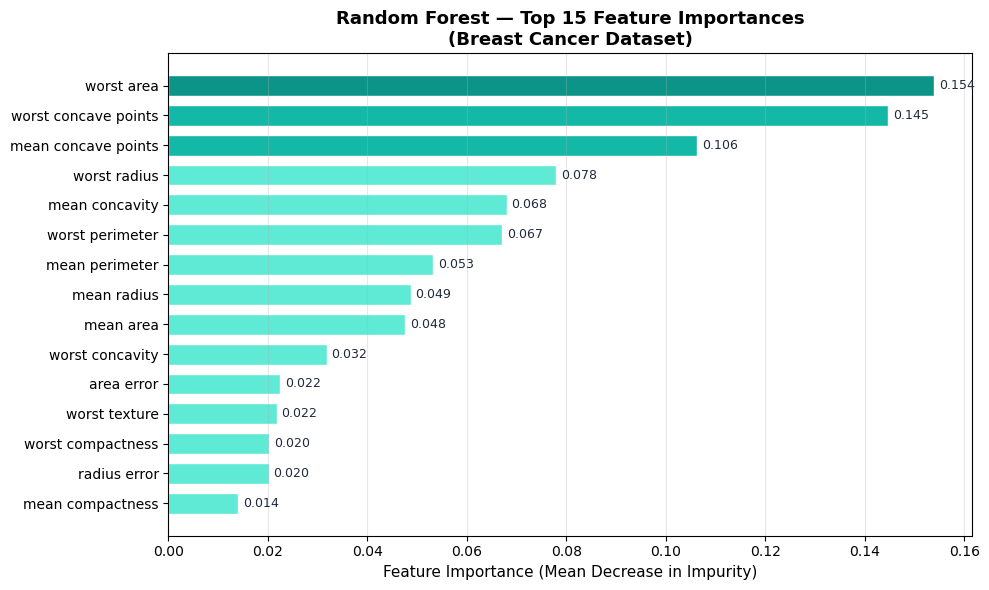


🏆 Most important feature: 'worst area' (0.1539)
   Top 3 features account for 40.5% of total importance


In [ ]:
# Plot feature importances
importances = rf_c.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 15 features
top_n = 15
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_names = [feature_names[i] for i in top_indices]

# Color bars by rank
colors = ['#0D9488' if i == 0 else '#14B8A6' if i < 3 else '#5EEAD4' for i in range(top_n)]

plt.figure(figsize=(10, 6))
bars = plt.barh(range(top_n), top_importances[::-1], color=colors[::-1], edgecolor='white', height=0.7)
plt.yticks(range(top_n), top_names[::-1], fontsize=10)
plt.xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
plt.title('Random Forest — Top 15 Feature Importances\n(Breast Cancer Dataset)', fontsize=13, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_importances[::-1])):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, color='#1E293B')

plt.tight_layout()
plt.show()

print(f"\n🏆 Most important feature: '{top_names[0]}' ({top_importances[0]:.4f})")
print(f"   Top 3 features account for {sum(top_importances[:3]):.1%} of total importance")

---
## ⚙️ 9. Hyperparameter Tuning — Key Parameters

Random Forest has a few parameters worth knowing:

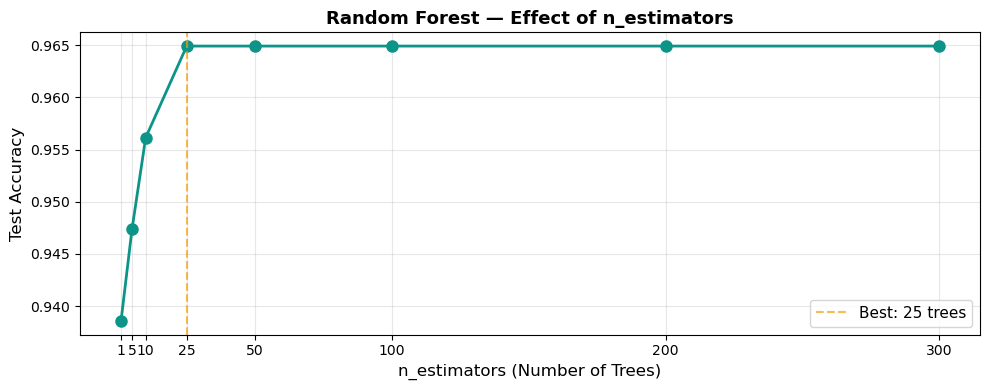


💡 Insight: After ~100 trees, accuracy plateaus.
   More trees = more computation, not necessarily better accuracy.
   Rule of thumb: Start with 100, go up if cross-validation improves.


In [ ]:
# Effect of n_estimators
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 300]
rf_test_scores = []

for n in n_trees_list:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=SEED)
    rf_temp.fit(X_c_train, y_c_train)
    rf_test_scores.append(accuracy_score(y_c_test, rf_temp.predict(X_c_test)))

plt.figure(figsize=(10, 4))
plt.plot(n_trees_list, rf_test_scores, 'o-', color='#0D9488', linewidth=2, markersize=8)
plt.xlabel('n_estimators (Number of Trees)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Random Forest — Effect of n_estimators', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(n_trees_list)

# Mark point of diminishing returns
best_idx = np.argmax(rf_test_scores)
plt.axvline(x=n_trees_list[best_idx], color='#F59E0B', linestyle='--', alpha=0.7,
            label=f'Best: {n_trees_list[best_idx]} trees')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Insight: After ~100 trees, accuracy plateaus.")
print("   More trees = more computation, not necessarily better accuracy.")
print("   Rule of thumb: Start with 100, go up if cross-validation improves.")

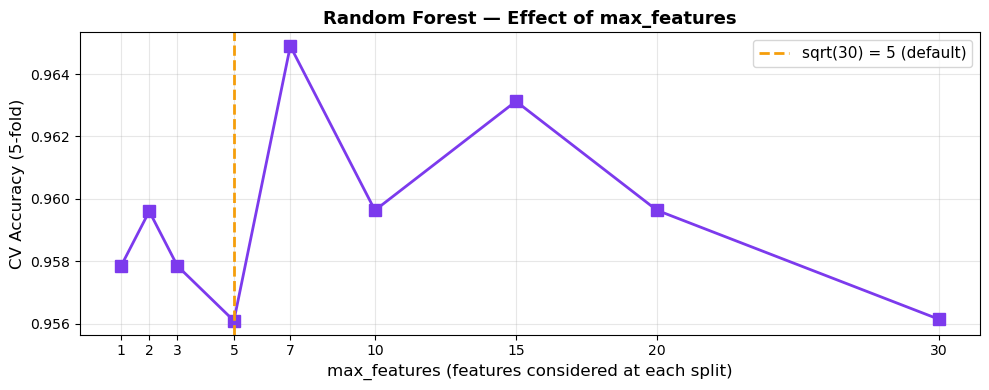


✅ Default sqrt(30) = 5 features is a reliable starting point
   Far right (30 features) = pure Bagging — notice it performs worse!
   Far left (1 feature) = too random, trees can't find good splits


In [ ]:
# Effect of max_features — the key RF hyperparameter
n_features = X_c.shape[1]  # 30 features
max_features_options = [1, 2, 3, 5, 7, 10, 15, 20, 30]  # 30 = all features = pure bagging
mf_scores = []

for mf in max_features_options:
    rf_mf = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=SEED)
    scores = cross_val_score(rf_mf, X_c, y_c, cv=5)
    mf_scores.append(scores.mean())

# Mark sqrt(30) ≈ 5.5
sqrt_val = int(np.sqrt(n_features))

plt.figure(figsize=(10, 4))
plt.plot(max_features_options, mf_scores, 's-', color='#7C3AED', linewidth=2, markersize=8)
plt.axvline(x=sqrt_val, color='#F59E0B', linestyle='--', linewidth=2,
            label=f'sqrt({n_features}) = {sqrt_val} (default)')
plt.xlabel('max_features (features considered at each split)', fontsize=12)
plt.ylabel('CV Accuracy (5-fold)', fontsize=12)
plt.title('Random Forest — Effect of max_features', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(max_features_options)
plt.tight_layout()
plt.show()

print(f"\n✅ Default sqrt({n_features}) = {sqrt_val} features is a reliable starting point")
print(f"   Far right (30 features) = pure Bagging — notice it performs worse!")
print(f"   Far left (1 feature) = too random, trees can't find good splits")

---
## 🆓 10. Out-Of-Bag (OOB) Score — Free Validation

Remember: each tree only sees ~63% of training data.  
The remaining 37% (**Out-Of-Bag samples**) can be used to validate each tree **for free**, without a separate test set!

> `oob_score=True` gives you a validation estimate with zero extra data. Very useful for small datasets.

In [ ]:
rf_oob = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,     # ← Enable OOB scoring
    random_state=SEED
)
rf_oob.fit(X_c_train, y_c_train)

oob_score  = rf_oob.oob_score_
test_score = accuracy_score(y_c_test, rf_oob.predict(X_c_test))
cv_score   = cross_val_score(rf_oob, X_c, y_c, cv=5).mean()

print("=" * 50)
print("  Validation Method Comparison")
print("=" * 50)
print(f"  OOB Score       : {oob_score:.4f}  ← FREE, no extra data")
print(f"  Test Set Score  : {test_score:.4f}  ← requires held-out set")
print(f"  5-Fold CV Score : {cv_score:.4f}  ← most reliable, but slower")
print("=" * 50)
print("\n💡 OOB score is a great proxy for test performance.")
print("   Especially useful when your dataset is small!")

  Validation Method Comparison
  OOB Score       : 0.9560  ← FREE, no extra data
  Test Set Score  : 0.9649  ← requires held-out set
  5-Fold CV Score : 0.9561  ← most reliable, but slower

💡 OOB score is a great proxy for test performance.
   Especially useful when your dataset is small!


---
## 🏁 11. Final Comparison — Decision Boundary Visualisation

Let's visually see how the three models differ in their decision boundaries using a 2D dataset.

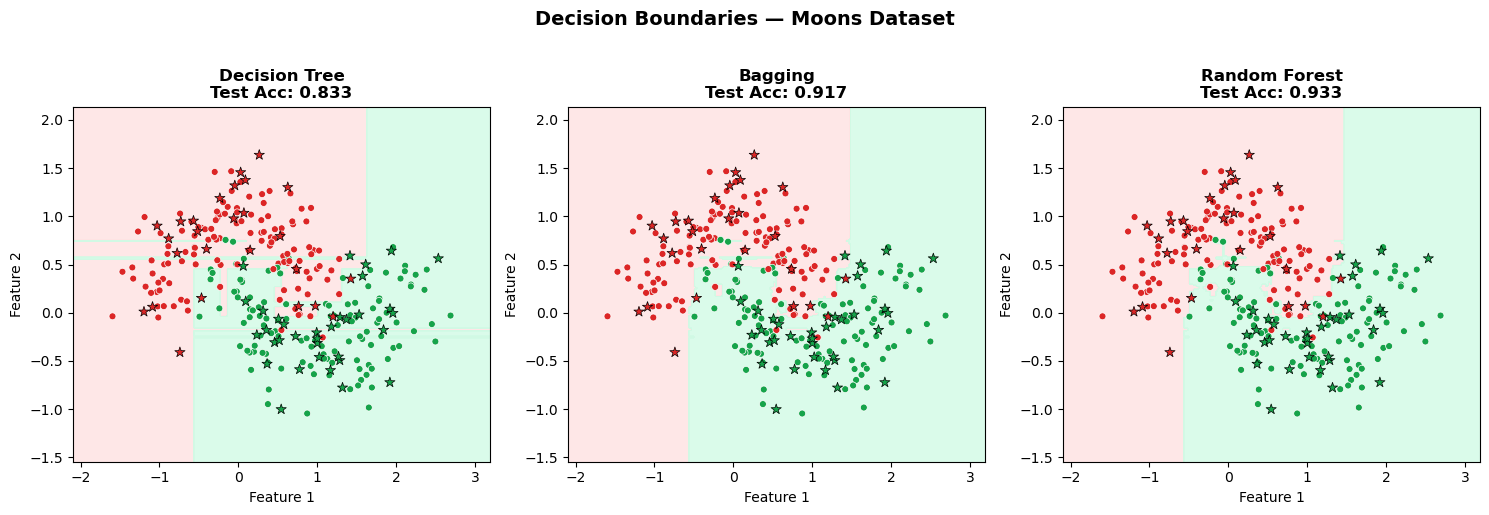


💡 Notice:
  → Decision Tree: jagged, irregular boundary — overfits to noise
  → Bagging: smoother, but still somewhat noisy
  → Random Forest: smoothest boundary — generalises best


In [ ]:
from sklearn.datasets import make_moons
from matplotlib.colors import ListedColormap

# Non-linear dataset to show power of ensembles
X_vis, y_vis = make_moons(n_samples=300, noise=0.25, random_state=SEED)
X_v_train, X_v_test, y_v_train, y_v_test = train_test_split(X_vis, y_vis, test_size=0.2, random_state=SEED)

models = [
    ("Decision Tree",  DecisionTreeClassifier(random_state=SEED)),
    ("Bagging",        BaggingClassifier(n_estimators=100, random_state=SEED)),
    ("Random Forest",  RandomForestClassifier(n_estimators=100, random_state=SEED)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Grid for decision boundary
xx, yy = np.meshgrid(np.linspace(X_vis[:, 0].min()-0.5, X_vis[:, 0].max()+0.5, 300),
                     np.linspace(X_vis[:, 1].min()-0.5, X_vis[:, 1].max()+0.5, 300))

cmap_bg = ListedColormap(['#FEE2E2', '#D1FAE5'])
cmap_pt = ListedColormap(['#DC2626', '#16A34A'])

for ax, (name, model) in zip(axes, models):
    model.fit(X_v_train, y_v_train)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    test_acc = accuracy_score(y_v_test, model.predict(X_v_test))

    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    ax.scatter(X_v_train[:, 0], X_v_train[:, 1], c=y_v_train,
               cmap=cmap_pt, s=25, edgecolors='white', linewidths=0.5, label='Train')
    ax.scatter(X_v_test[:, 0], X_v_test[:, 1], c=y_v_test,
               cmap=cmap_pt, s=60, marker='*', edgecolors='black', linewidths=0.5, label='Test')
    ax.set_title(f'{name}\nTest Acc: {test_acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Decision Boundaries — Moons Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Notice:")
print("  → Decision Tree: jagged, irregular boundary — overfits to noise")
print("  → Bagging: smoother, but still somewhat noisy")
print("  → Random Forest: smoothest boundary — generalises best")

---
## 📋 12. Final Summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              From Trees to Forests — Summary                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DECISION TREE                                               ║
║  ✗ Overfits (high variance)                                  ║
║  ✗ Unstable — sensitive to small data changes                ║
║  ✓ Interpretable, fast                                       ║
║                                                              ║
║  BAGGING                                                     ║
║  ✓ Reduces variance via bootstrap + majority vote            ║
║  ✗ Trees still correlated (share strong features)            ║
║  ✗ Less interpretable                                        ║
║                                                              ║
║  RANDOM FOREST                                               ║
║  ✓ Bagging + random feature subsets                          ║
║  ✓ Decorrelated trees → errors cancel better                 ║
║  ✓ Free OOB validation                                       ║
║  ✓ Free feature importances                                  ║
║  → Industry standard for tabular data                        ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  KEY HYPERPARAMETERS                                         ║
║  n_estimators   → 100 to start, more = diminishing returns   ║
║  max_features   → sqrt(n) for classification (default)       ║
║  max_depth      → None by default (fully grown)              ║
║  oob_score      → True (free validation!)                    ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT: Boosting — what if trees learn from each other?       ║
╚══════════════════════════════════════════════════════════════╝
""")

---
## 🏋️ Practice Exercises

Try these on your own:

1. **Change `max_features` to 1** in RandomForestClassifier. What happens to accuracy? Why?

2. **Set `bootstrap=False`** in BaggingClassifier. What changes? (Hint: this is called Pasting, not Bagging)

3. **Try `max_depth=3`** in RandomForestClassifier. Does limiting tree depth help or hurt?

4. **Print `rf.feature_importances_`** and rank the features. Do the top features make intuitive sense for breast cancer diagnosis?

5. **Challenge:** Build a `ManualRandomForest` class similar to `ManualBagging` above, but add feature randomness at each split using `max_features='sqrt'` in the DecisionTreeClassifier.